<a href="https://colab.research.google.com/github/kyathi15/pcos_ML_prediction/blob/main/pcos_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving pcos_real_only_dataset.xlsx to pcos_real_only_dataset.xlsx


In [2]:
import pandas as pd

df = pd.read_excel("pcos_real_only_dataset.xlsx")

df.head()

,Sl. No,Patient File No.,PCOS (Y/N),Age (yrs),Weight (Kg),Height(Cm),BMI,Blood Group,Pulse rate(bpm),RR (breaths/min),...,Fast food (Y/N),Reg.Exercise(Y/N),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm),Data_Source
0,1,PT-10000,N,30,69.98,167.71,23.19,A-,72,22,...,N,Y,105.48,76.10,2.0,4.0,10.0,13.0,6.18,PCOS_extended_dataset (real)
1,2,PT-10001,N,36,63.71,154.06,25.44,B+,70,18,...,N,Y,115.88,79.12,2.0,3.0,13.0,11.0,6.82,PCOS_extended_dataset (real)
2,3,PT-10002,N,36,51.85,149.06,23.93,O+,80,20,...,N,N,112.22,80.92,1.0,1.0,14.0,17.0,2.57,PCOS_extended_dataset (real)
3,4,PT-10003,Y,29,66.89,148.63,27.89,O+,72,18,...,N,Y,104.62,69.90,1.0,1.0,12.0,14.0,9.96,PCOS_extended_dataset (real)
4,5,PT-10004,N,33,52.54,150.77,23.08,B+,72,18,...,N,N,99.18,70.33,5.0,2.0,11.5,4.7,6.66,PCOS_extended_dataset (real)


In [3]:
df.shape

(3556, 45)

In [4]:
df.isnull().sum()

,0
Sl. No,0
Patient File No.,0
PCOS (Y/N),0
Age (yrs),0
Weight (Kg),0
Height(Cm),0
BMI,0
Blood Group,0
Pulse rate(bpm),0
RR (breaths/min),0


In [6]:
df.duplicated().sum()


np.int64(0)

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3556 entries, 0 to 3555
Data columns (total 45 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Sl. No                 3556 non-null   int64  
 1   Patient File No.       3556 non-null   object 
 2   PCOS (Y/N)             3556 non-null   object 
 3   Age (yrs)              3556 non-null   int64  
 4   Weight (Kg)            3556 non-null   float64
 5   Height(Cm)             3556 non-null   float64
 6   BMI                    3556 non-null   float64
 7   Blood Group            3556 non-null   object 
 8   Pulse rate(bpm)        3556 non-null   int64  
 9   RR (breaths/min)       3556 non-null   int64  
 10  Hb(g/dl)               3556 non-null   float64
 11  Cycle(R/I)             3556 non-null   object 
 12  Cycle length(days)     3556 non-null   int64  
 13  Marraige Status (Yrs)  3556 non-null   float64
 14  Pregnant(Y/N)          3556 non-null   object 
 15  No. 

In [9]:
df.describe()

,Sl. No,Age (yrs),Weight (Kg),Height(Cm),BMI,Pulse rate(bpm),RR (breaths/min),Hb(g/dl),Cycle length(days),Marraige Status (Yrs),...,Vit D3 (ng/mL),PRG(ng/mL),RBS(mg/dl),BP _Systolic (mmHg),BP _Diastolic (mmHg),Follicle No. (L),Follicle No. (R),Avg. F size (L) (mm),Avg. F size (R) (mm),Endometrium (mm)
count,3556.000000,3556.000000,3556.000000,3556.000000,3556.000000,3556.000000,3556.000000,3556.000000,3556.000000,3556.000000,...,3556.000000,3556.000000,3556.000000,3556.000000,3556.000000,3556.000000,3556.000000,3556.000000,3556.000000,3556.000000
mean,1778.500000,31.278684,61.921991,156.831890,25.047953,76.025591,20.221316,11.561845,8.692070,8.420051,...,33.805816,1.921372,98.228301,115.919845,76.903344,8.397458,8.638124,13.128687,13.425309,8.559885
std,1026.673106,6.884844,12.566718,6.107718,4.595797,7.333960,2.292458,1.178133,9.576604,5.327929,...,191.357053,3.865591,18.837749,9.946072,7.160891,5.981642,5.879560,4.376343,4.355279,2.321670
min,1.000000,18.000000,29.500000,134.600000,9.950000,13.000000,16.000000,8.000000,0.000000,0.000000,...,-5.000000,-1.610000,51.000000,11.530000,7.680000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,889.750000,26.000000,53.100000,152.627500,21.850000,72.000000,18.000000,10.780000,4.000000,4.000000,...,19.437500,0.300000,88.000000,109.000000,71.477500,4.000000,4.000000,10.140000,11.000000,6.990000
50%,1778.500000,31.000000,60.605000,156.825000,24.725000,74.000000,20.000000,11.400000,5.000000,8.000000,...,25.600000,0.560000,96.085000,115.020000,78.000000,7.000000,7.000000,14.000000,14.000000,8.475000
75%,2667.250000,36.000000,69.787500,160.662500,28.000000,79.000000,22.000000,12.280000,7.000000,12.000000,...,34.432500,2.095000,106.180000,122.302500,81.792500,12.000000,12.000000,16.350000,17.000000,10.050000
max,3556.000000,48.000000,122.050000,180.390000,45.670000,95.000000,28.000000,16.300000,52.000000,30.000000,...,6014.660000,85.000000,350.000000,152.000000,104.270000,29.940000,29.540000,24.000000,24.000000,18.680000


In [10]:
df["PCOS (Y/N)"].value_counts()

,count
PCOS (Y/N),
N,2496
Y,1060


In [11]:
df["PCOS (Y/N)"].value_counts(normalize=True) * 100


,proportion
PCOS (Y/N),
N,70.191226
Y,29.808774


In [12]:
for i, col in enumerate(df.columns):
    print(i, ":", col)

0 : Sl. No
1 : Patient File No.
2 : PCOS (Y/N)
3 : Age (yrs)
4 : Weight (Kg)
5 : Height(Cm)
6 : BMI
7 : Blood Group
8 : Pulse rate(bpm)
9 : RR (breaths/min)
10 : Hb(g/dl)
11 : Cycle(R/I)
12 : Cycle length(days)
13 : Marraige Status (Yrs)
14 : Pregnant(Y/N)
15 : No. of aborptions
16 : I beta-HCG(mIU/mL)
17 : II beta-HCG(mIU/mL)
18 : FSH(mIU/mL)
19 : LH(mIU/mL)
20 : FSH/LH
21 : Hip(inch)
22 : Waist(inch)
23 : Waist:Hip Ratio
24 : TSH (mIU/L)
25 : AMH(ng/mL)
26 : PRL(ng/mL)
27 : Vit D3 (ng/mL)
28 : PRG(ng/mL)
29 : RBS(mg/dl)
30 : Weight gain(Y/N)
31 : hair growth(Y/N)
32 : Skin darkening (Y/N)
33 : Hair loss(Y/N)
34 : Pimples(Y/N)
35 : Fast food (Y/N)
36 : Reg.Exercise(Y/N)
37 : BP _Systolic (mmHg)
38 : BP _Diastolic (mmHg)
39 : Follicle No. (L)
40 : Follicle No. (R)
41 : Avg. F size (L) (mm)
42 : Avg. F size (R) (mm)
43 : Endometrium (mm)
44 : Data_Source


In [ ]:
#data cleaning

In [14]:
df_clean = df.copy()

In [15]:
df_clean.isnull().sum()

,0
Sl. No,0
Patient File No.,0
PCOS (Y/N),0
Age (yrs),0
Weight (Kg),0
Height(Cm),0
BMI,0
Blood Group,0
Pulse rate(bpm),0
RR (breaths/min),0


In [16]:
df_clean = df_clean.drop(
    columns=["Sl. No", "Patient File No."],
    errors="ignore"
)

In [17]:
df_clean.select_dtypes(include="object").columns

Index(['PCOS (Y/N)', 'Blood Group', 'Cycle(R/I)', 'Pregnant(Y/N)',
       'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)',
       'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)',
       'Reg.Exercise(Y/N)', 'Data_Source'],
      dtype='object')

In [18]:
for col in df_clean.select_dtypes(include="object").columns:
    print("\n", col)
    print(df_clean[col].unique())


 PCOS (Y/N)
['N' 'Y']

 Blood Group
['A-' 'B+' 'O+' 'A+' 'AB+' 'B-' 'O-' 'AB-']

 Cycle(R/I)
['I' 'R']

 Pregnant(Y/N)
['Y' 'N']

 Weight gain(Y/N)
['N' 'Y']

 hair growth(Y/N)
['Y' 'N']

 Skin darkening (Y/N)
['N' 'Y']

 Hair loss(Y/N)
['N' 'Y']

 Pimples(Y/N)
['Y' 'N']

 Fast food (Y/N)
['N' 'Y']

 Reg.Exercise(Y/N)
['Y' 'N']

 Data_Source
['PCOS_extended_dataset (real)' 'pcos_dataset (real, reduced fields)'
 'PCOS Dataset.xlsx (real, extended clinical)'
 'vitD_donnees_2022Mai (real, French clinical)']


In [19]:
df_clean = df_clean.drop(columns=["Data_Source"], errors="ignore")

In [20]:
X = df_clean.drop(columns=["PCOS (Y/N)"])
y = df_clean["PCOS (Y/N)"]

In [21]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3556, 41)
y shape: (3556,)


In [ ]:
#mapping

In [22]:
y = y.map({"N": 0, "Y": 1})

In [23]:
y.value_counts()

,count
PCOS (Y/N),
0,2496
1,1060


In [24]:
binary_columns = [
    "Pregnant(Y/N)",
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)",
    "Fast food (Y/N)",
    "Reg.Exercise(Y/N)"
]

for col in binary_columns:
    X[col] = X[col].map({"N": 0, "Y": 1})

In [26]:
X["Cycle(R/I)"] = X["Cycle(R/I)"].map({"R": 0, "I": 1})

In [27]:
print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nTarget distribution:")
print(y.value_counts())

X shape: (3556, 41)
y shape: (3556,)

Target distribution:
PCOS (Y/N)
0    2496
1    1060
Name: count, dtype: int64


EDA

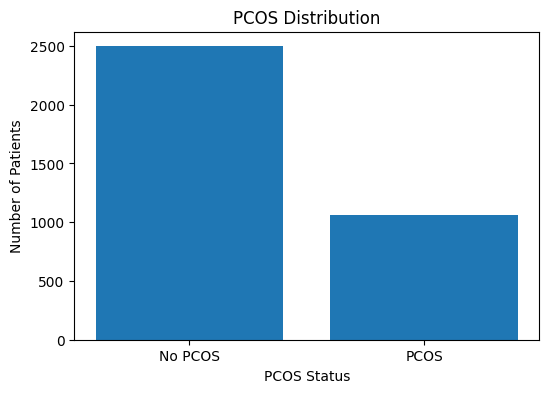

In [28]:
import matplotlib.pyplot as plt

pcos_counts = y.value_counts().sort_index()

plt.figure(figsize=(6, 4))
plt.bar(["No PCOS", "PCOS"], pcos_counts.values)
plt.xlabel("PCOS Status")
plt.ylabel("Number of Patients")
plt.title("PCOS Distribution")
plt.show()

AGE RANGE

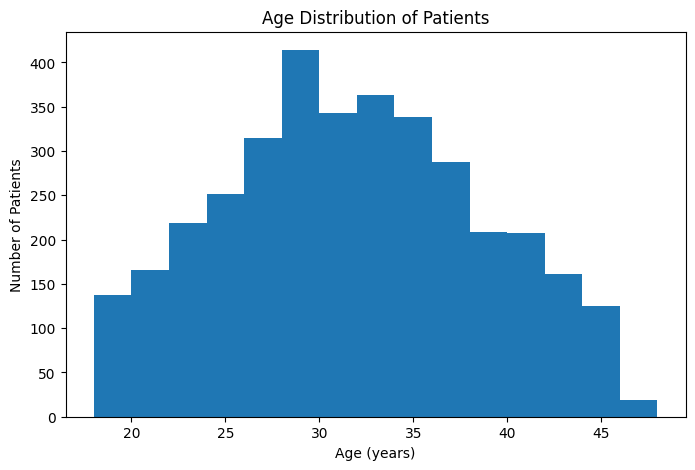

In [29]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["Age (yrs)"], bins=15)
plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")
plt.title("Age Distribution of Patients")
plt.show()

BMI DISTRIBUTION


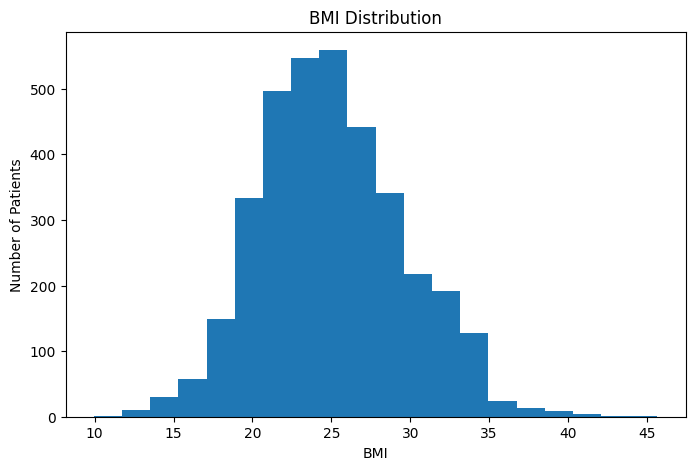

In [30]:
plt.figure(figsize=(8, 5))
plt.hist(df_clean["BMI"], bins=20)
plt.xlabel("BMI")
plt.ylabel("Number of Patients")
plt.title("BMI Distribution")
plt.show()

pcos vs bmi

/tmp/ipykernel_579/1396795972.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


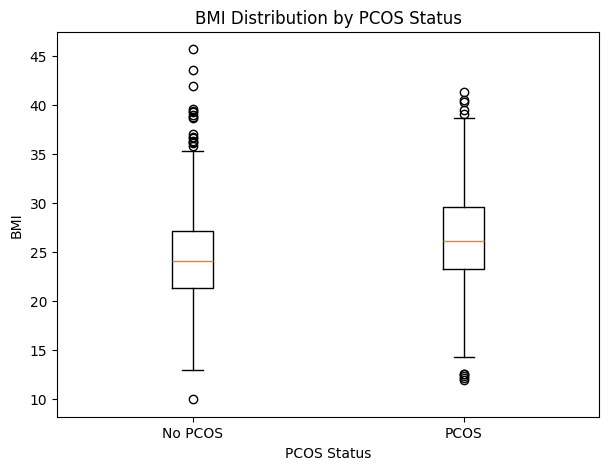

In [31]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        df_clean.loc[y == 0, "BMI"],
        df_clean.loc[y == 1, "BMI"]
    ],
    labels=["No PCOS", "PCOS"]
)

plt.xlabel("PCOS Status")
plt.ylabel("BMI")
plt.title("BMI Distribution by PCOS Status")
plt.show()

PCOS VS AGE

/tmp/ipykernel_579/2548106907.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


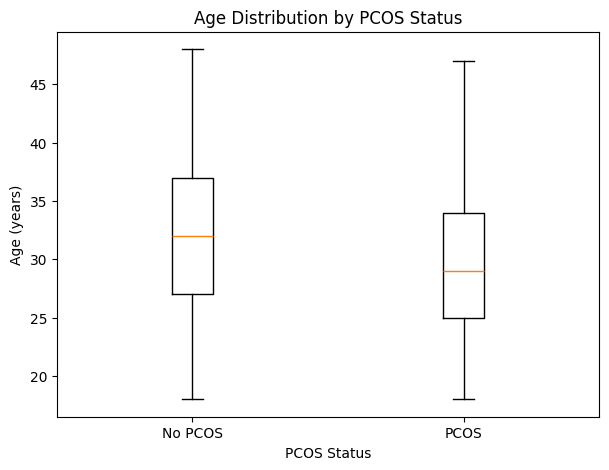

In [32]:
plt.figure(figsize=(7, 5))

plt.boxplot(
    [
        df_clean.loc[y == 0, "Age (yrs)"],
        df_clean.loc[y == 1, "Age (yrs)"]
    ],
    labels=["No PCOS", "PCOS"]
)

plt.xlabel("PCOS Status")
plt.ylabel("Age (years)")
plt.title("Age Distribution by PCOS Status")
plt.show()

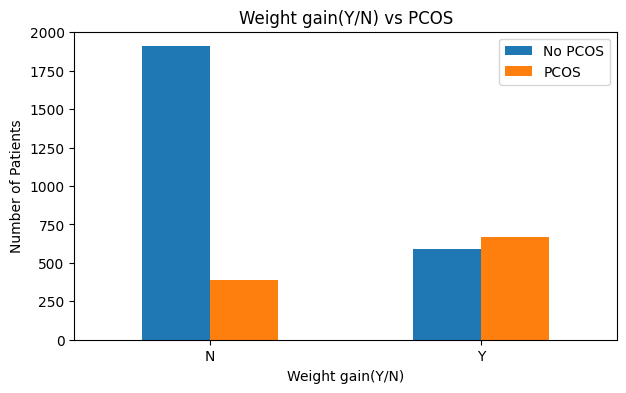

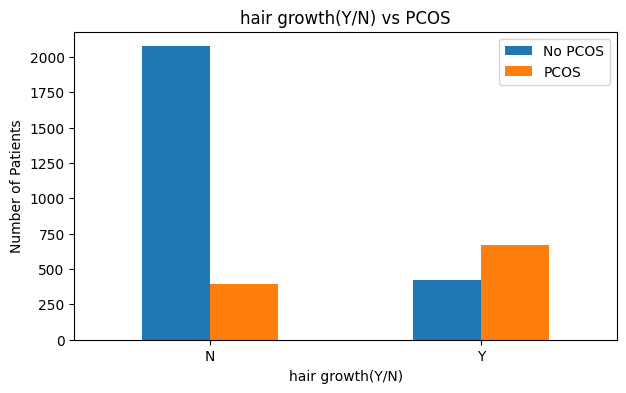

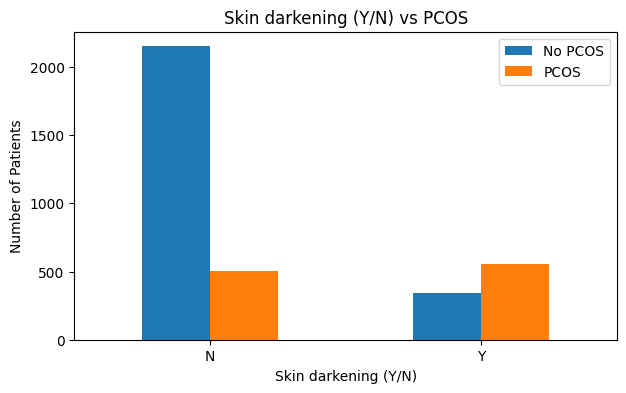

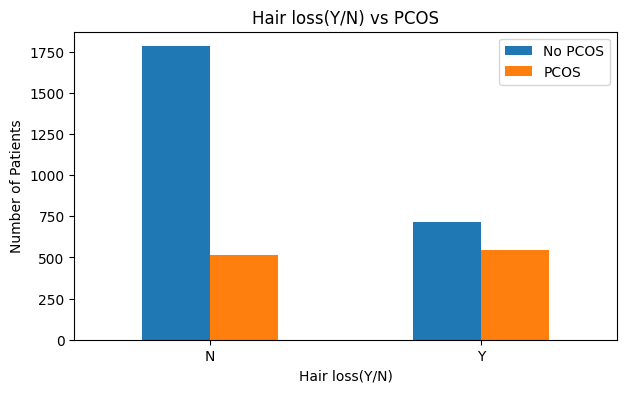

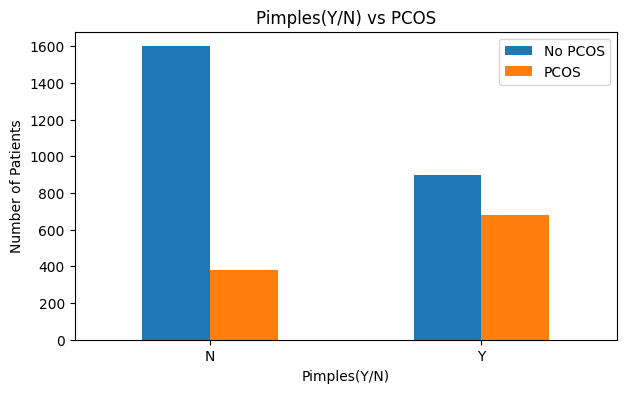

In [33]:
symptom_columns = [
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)"
]

for col in symptom_columns:
    counts = df_clean.groupby(col)["PCOS (Y/N)"].value_counts().unstack(fill_value=0)

    counts.plot(kind="bar", figsize=(7, 4))

    plt.title(f"{col} vs PCOS")
    plt.xlabel(col)
    plt.ylabel("Number of Patients")
    plt.xticks(rotation=0)
    plt.legend(["No PCOS", "PCOS"])
    plt.show()

PERCENTAGE ANALYSIS


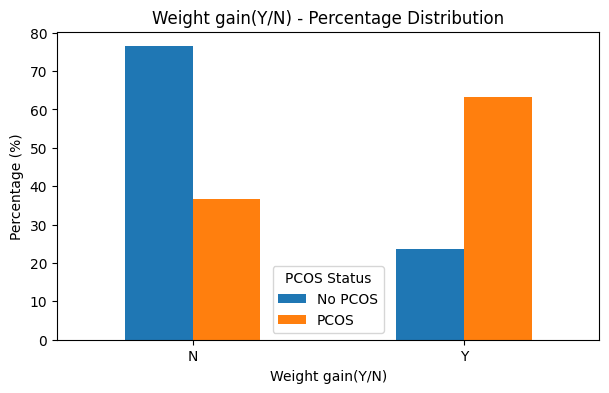

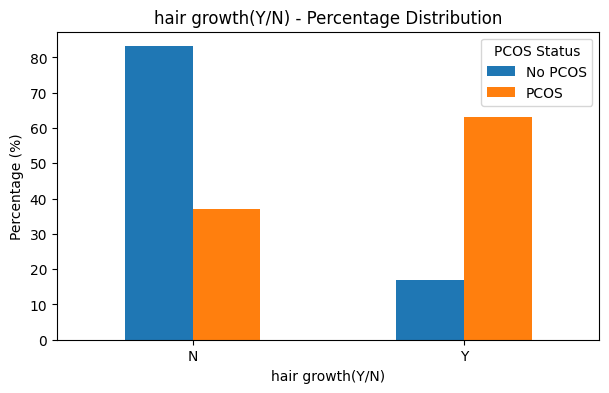

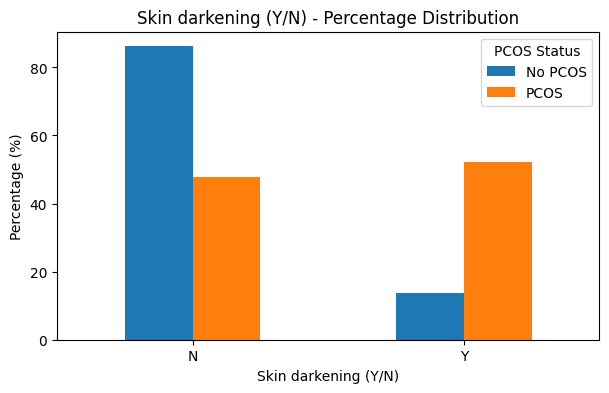

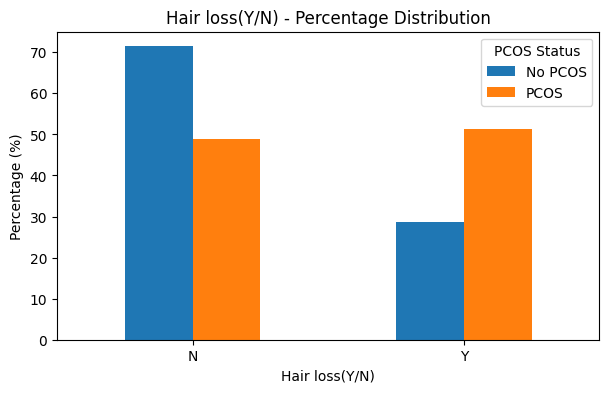

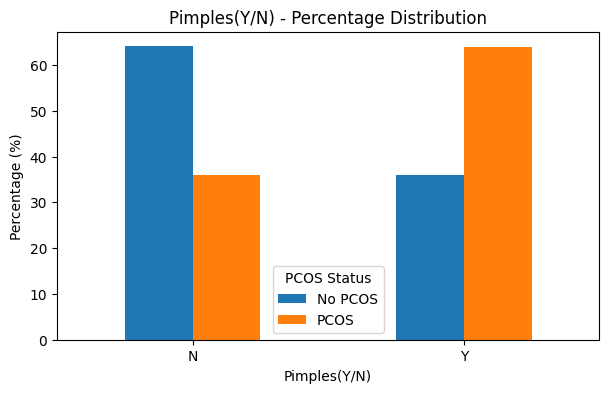

In [34]:
symptom_columns = [
    "Weight gain(Y/N)",
    "hair growth(Y/N)",
    "Skin darkening (Y/N)",
    "Hair loss(Y/N)",
    "Pimples(Y/N)"
]

for col in symptom_columns:
    temp = pd.crosstab(
        df_clean[col],
        y,
        normalize="columns"
    ) * 100

    temp.columns = ["No PCOS", "PCOS"]

    temp.plot(
        kind="bar",
        figsize=(7, 4)
    )

    plt.title(f"{col} - Percentage Distribution")
    plt.xlabel(col)
    plt.ylabel("Percentage (%)")
    plt.xticks(rotation=0)
    plt.legend(title="PCOS Status")
    plt.show()

In [ ]:
#hormone analysis

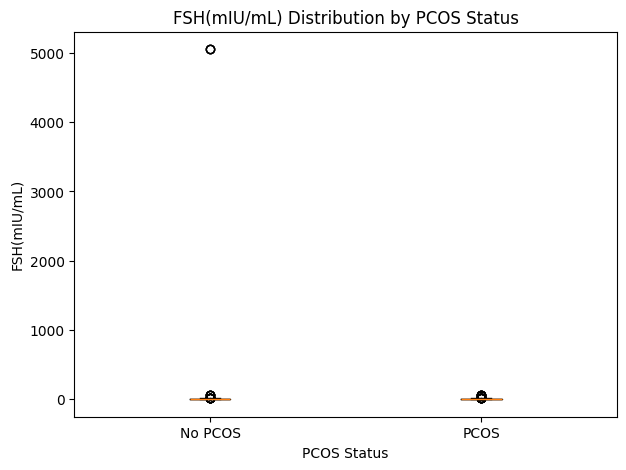

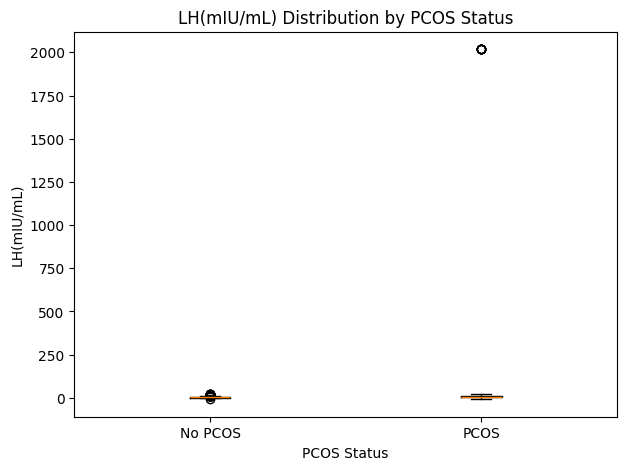

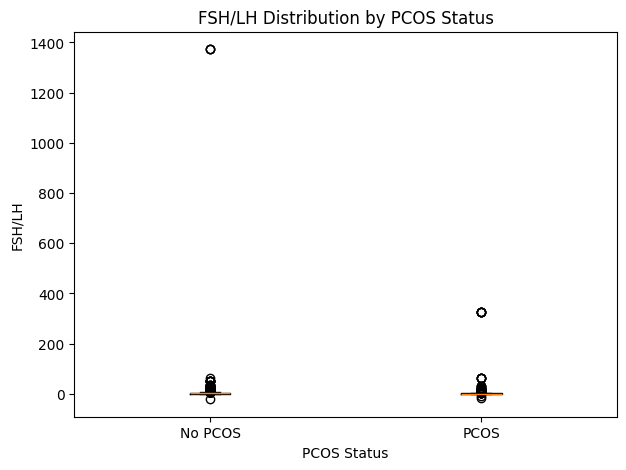

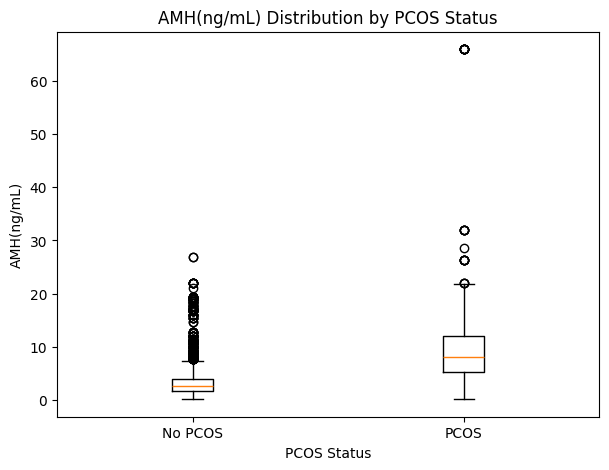

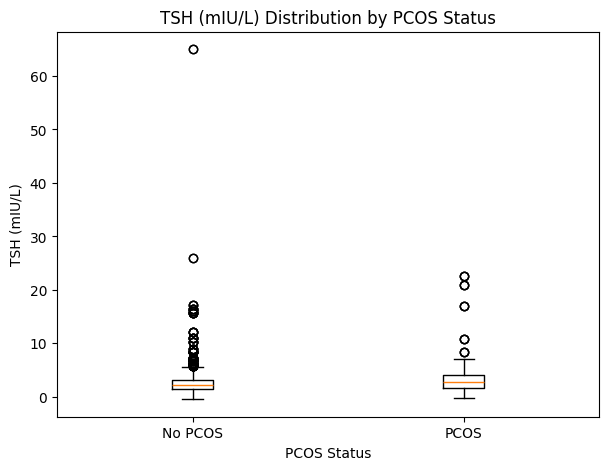

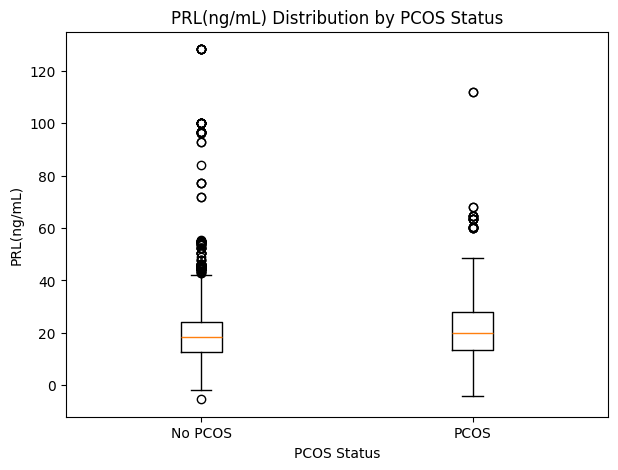

In [35]:
hormone_columns = [
    "FSH(mIU/mL)",
    "LH(mIU/mL)",
    "FSH/LH",
    "AMH(ng/mL)",
    "TSH (mIU/L)",
    "PRL(ng/mL)"
]

for col in hormone_columns:
    plt.figure(figsize=(7, 5))

    plt.boxplot(
        [
            df_clean.loc[y == 0, col],
            df_clean.loc[y == 1, col]
        ],
        tick_labels=["No PCOS", "PCOS"]
    )

    plt.xlabel("PCOS Status")
    plt.ylabel(col)
    plt.title(f"{col} Distribution by PCOS Status")
    plt.show()

In [36]:
numerical_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns

df_clean[numerical_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
Age (yrs),3556.0,31.278684,6.884844,18.00,26.0000,31.000,36.0000,48.00
Weight (Kg),3556.0,61.921991,12.566718,29.50,53.1000,60.605,69.7875,122.05
Height(Cm),3556.0,156.831890,6.107718,134.60,152.6275,156.825,160.6625,180.39
BMI,3556.0,25.047953,4.595797,9.95,21.8500,24.725,28.0000,45.67
Pulse rate(bpm),3556.0,76.025591,7.333960,13.00,72.0000,74.000,79.0000,95.00
RR (breaths/min),3556.0,20.221316,2.292458,16.00,18.0000,20.000,22.0000,28.00
Hb(g/dl),3556.0,11.561845,1.178133,8.00,10.7800,11.400,12.2800,16.30
Cycle length(days),3556.0,8.692070,9.576604,0.00,4.0000,5.000,7.0000,52.00
Marraige Status (Yrs),3556.0,8.420051,5.327929,0.00,4.0000,8.000,12.0000,30.00
No. of aborptions,3556.0,0.297807,0.679957,0.00,0.0000,0.000,0.0000,5.00


CORRELATION HEATMAP

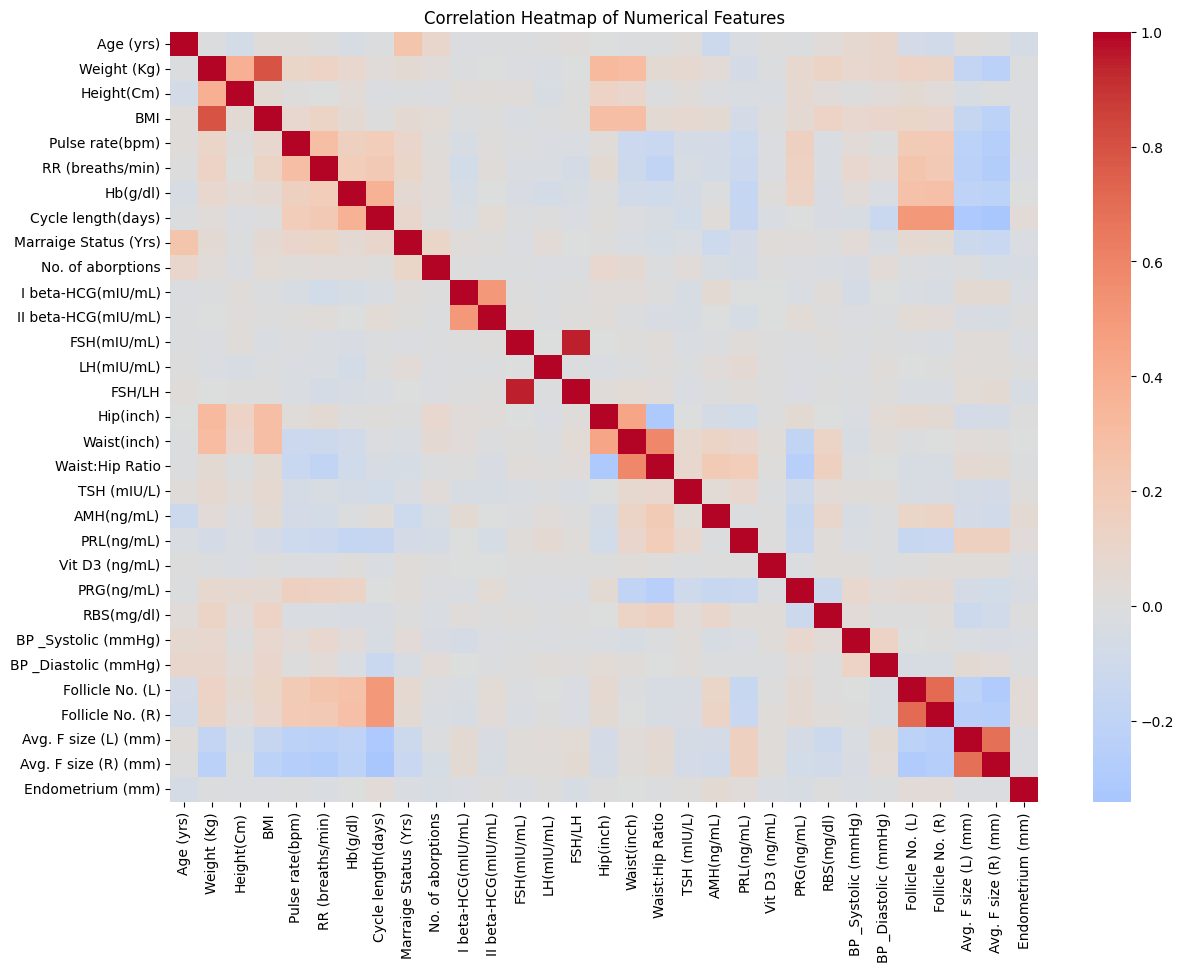

In [37]:
import seaborn as sns

plt.figure(figsize=(14, 10))

correlation = df_clean[numerical_columns].corr()

sns.heatmap(
    correlation,
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.show()

OUTLIERS CHECKING

In [38]:
# Check outliers using IQR

numerical_columns = df_clean.select_dtypes(
    include=["int64", "float64"]
).columns

outlier_summary = []

for col in numerical_columns:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = ((df_clean[col] < lower_bound) |
                (df_clean[col] > upper_bound)).sum()

    outlier_summary.append([col, outliers])

outlier_df = pd.DataFrame(
    outlier_summary,
    columns=["Feature", "Number of Outliers"]
)

outlier_df.sort_values(
    "Number of Outliers",
    ascending=False
)

,Feature,Number of Outliers
11,II beta-HCG(mIU/mL),772
9,No. of aborptions,707
10,I beta-HCG(mIU/mL),556
7,Cycle length(days),475
22,PRG(ng/mL),462
14,FSH/LH,349
4,Pulse rate(bpm),284
13,LH(mIU/mL),221
19,AMH(ng/mL),219
17,Waist:Hip Ratio,182


Data Preprocessing

In [39]:
df_clean.dtypes

,0
PCOS (Y/N),object
Age (yrs),int64
Weight (Kg),float64
Height(Cm),float64
BMI,float64
Blood Group,object
Pulse rate(bpm),int64
RR (breaths/min),int64
Hb(g/dl),float64
Cycle(R/I),object


In [40]:
# Separate target variable and input features

y = df_clean["PCOS (Y/N)"].map({"N": 0, "Y": 1})

X = df_clean.drop(columns=["PCOS (Y/N)"])

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (3556, 41)
y shape: (3556,)


In [41]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

print("\nNumber of numerical features:", len(numerical_features))

Categorical features:
['Blood Group', 'Cycle(R/I)', 'Pregnant(Y/N)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']

Number of categorical features: 10

Number of numerical features: 31


In [42]:
categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

print("Categorical features:")
print(categorical_features)

print("\nNumber of categorical features:", len(categorical_features))

print("\nNumber of numerical features:", len(numerical_features))

Categorical features:
['Blood Group', 'Cycle(R/I)', 'Pregnant(Y/N)', 'Weight gain(Y/N)', 'hair growth(Y/N)', 'Skin darkening (Y/N)', 'Hair loss(Y/N)', 'Pimples(Y/N)', 'Fast food (Y/N)', 'Reg.Exercise(Y/N)']

Number of categorical features: 10

Number of numerical features: 31


TRAINING and TESTING

In [43]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts())

print("\nTesting target distribution:")
print(y_test.value_counts())

Training data: (2844, 41)
Testing data: (712, 41)

Training target distribution:
PCOS (Y/N)
0    1996
1     848
Name: count, dtype: int64

Testing target distribution:
PCOS (Y/N)
0    500
1    212
Name: count, dtype: int64


CATEGORICAL to NUMERICAL

In [44]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

print("Preprocessor created successfully!")

Preprocessor created successfully!


In [45]:
# Fit the preprocessor ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data using the already-fitted preprocessor
X_test_processed = preprocessor.transform(X_test)

print("Processed training data shape:", X_train_processed.shape)
print("Processed testing data shape:", X_test_processed.shape)

Processed training data shape: (2844, 57)
Processed testing data shape: (712, 57)


In [46]:
print("Training processed type:", type(X_train_processed))
print("Testing processed type:", type(X_test_processed))

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training processed type: <class 'numpy.ndarray'>
Testing processed type: <class 'numpy.ndarray'>
Training shape: (2844, 57)
Testing shape: (712, 57)


In [47]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

In [48]:
#creating models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        random_state=42
    ),
    "SVM": SVC(probability=True, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

print("Models created successfully!")

Models created successfully!


In [49]:
#training models
trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")

    model.fit(X_train_processed, y_train)

    trained_models[name] = model

print("\nAll models trained successfully!")

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...
Training SVM...
Training Gradient Boosting...

All models trained successfully!


In [50]:
# testing the test
predictions = {}

for name, model in trained_models.items():
    predictions[name] = model.predict(X_test_processed)

print("Predictions generated successfully!")

Predictions generated successfully!


In [51]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

results = []

for name in trained_models:
    y_pred = predictions[name]

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.914326,0.864734,0.844340,0.854415
1,Decision Tree,0.981742,0.962791,0.976415,0.969555
2,Random Forest,0.998596,1.000000,0.995283,0.997636
3,SVM,0.977528,0.985149,0.938679,0.961353
4,Gradient Boosting,0.994382,0.990566,0.990566,0.990566


visual comparision

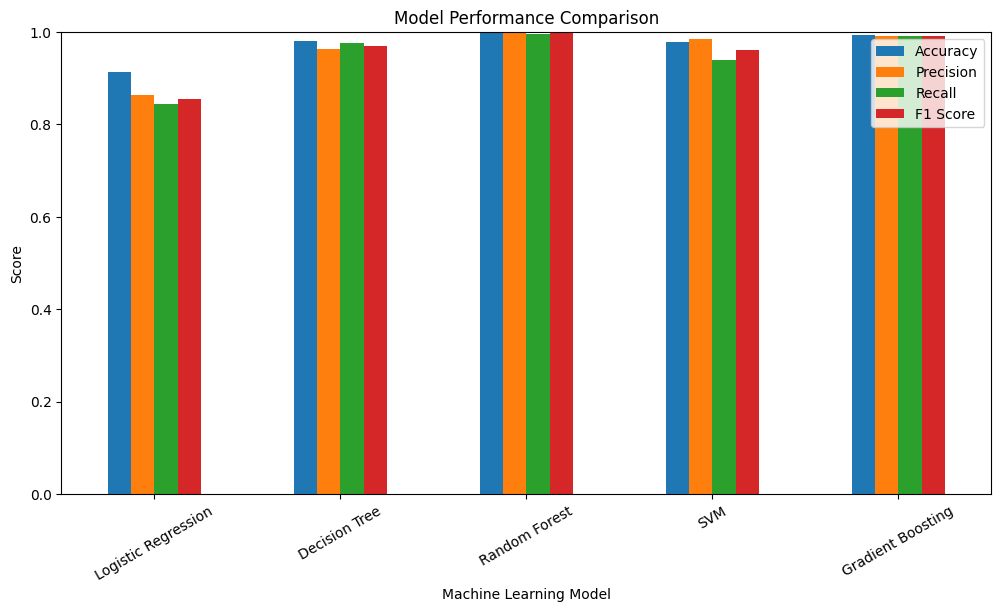

In [52]:
results_df.set_index("Model")[[
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score"
]].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xlabel("Machine Learning Model")
plt.xticks(rotation=30)
plt.ylim(0, 1)
plt.legend()
plt.show()

confusion matrix

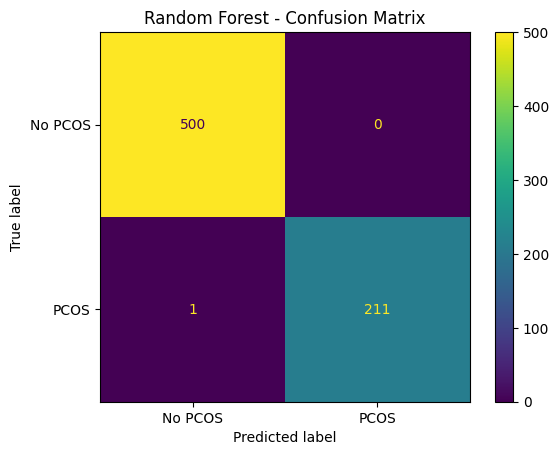

In [53]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

rf_model = trained_models["Random Forest"]

rf_predictions = rf_model.predict(X_test_processed)

cm = confusion_matrix(y_test, rf_predictions)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No PCOS", "PCOS"]
)

disp.plot()
plt.title("Random Forest - Confusion Matrix")
plt.show()

In [54]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_predictions,
    target_names=["No PCOS", "PCOS"]
))

              precision    recall  f1-score   support

     No PCOS       1.00      1.00      1.00       500
        PCOS       1.00      1.00      1.00       212

    accuracy                           1.00       712
   macro avg       1.00      1.00      1.00       712
weighted avg       1.00      1.00      1.00       712

